In [9]:

# [setup]
import os, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import json
from ucimlrepo import fetch_ucirepo

torch.set_float32_matmul_precision('high')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs('checkpoints', exist_ok=True)
print('Device:', DEVICE)

# --- AÑADIR ESTO PARA REPRODUCIBILIDAD EN GPU ---
if DEVICE == 'cuda':
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Advertencia: Esto puede hacer el código un poco más lento
    torch.use_deterministic_algorithms(True) 
    # Para algunas versiones de CUDA
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"


Device: cuda


In [10]:
# [model core] - REEMPLAZAR CELDA 3

# Función para inicializar los pesos
def init_weights(m, init_method='he'):
    if isinstance(m, nn.Linear):
        if init_method == 'he':
            # Inicialización He (buena para ReLU)
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        elif init_method == 'xavier':
            # Inicialización Xavier (buena para Tanh o Sigmoid)
            nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def make_mlp(d_in: int, d_hidden=(64, 64), d_out=1, dropout=0.0, 
             act_fn=nn.ReLU, # <--- CAMBIADO (ahora es un parámetro)
             use_bn=False):
    layers = []
    d_prev = d_in
    for i, h in enumerate(d_hidden):
        layers.append(nn.Linear(d_prev, h))
        if use_bn:
            layers.append(nn.BatchNorm1d(h))
        layers.append(act_fn()) # <--- Usa la función de activación
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        d_prev = h
    layers.append(nn.Linear(d_prev, d_out))
    return nn.Sequential(*layers)

@torch.no_grad()
def accuracy_bin(logits, y_true):
    preds = (logits.sigmoid() >= 0.5).float().view(-1)
    return (preds == y_true.view(-1)).float().mean().item()

@torch.no_grad()
def accuracy_multi(logits, y_true):
    preds = logits.argmax(1)
    return (preds == y_true).float().mean().item()

def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [11]:
# [compat: models with names FFNN / FFNN_MC] - (Modificada para d_hidden)

class FFNN(nn.Module):
    # Binario: salida 1
    def __init__(self, d0, d_hidden=(64, 64), dropout=0.0, use_bn=False, 
                 init_method='he', act_fn=nn.ReLU): # <--- AÑADIDO act_fn
        super().__init__()
        self.net = make_mlp(d0, d_hidden, 1, dropout=dropout, 
                            act_fn=act_fn, use_bn=use_bn) # <--- Pasado a make_mlp
        self.net.apply(lambda m: init_weights(m, init_method=init_method))
        
    def forward(self, x): 
        return self.net(x)

class FFNN_MC(nn.Module):
    # Multiclase: salida C
    # MODIFICADO: Acepta d_hidden=(capa1, capa2, ...)
    def __init__(self, d0, d_hidden=(64, 64), C=3, dropout=0.0, use_bn=False, init_method='he'):
        super().__init__()
        self.net = make_mlp(d0, d_hidden, C, dropout=dropout, act_fn=nn.ReLU, use_bn=use_bn)
        self.net.apply(lambda m: init_weights(m, init_method=init_method))

    def forward(self, x): 
        return self.net(x)

In [12]:
np.random.seed(42)
print("Cargando dataset Online News Popularity...")
online_news_popularity = fetch_ucirepo(id=332) 
X_df = online_news_popularity.data.features 
y_df = online_news_popularity.data.targets 

# Binarizar 'y' para clasificación
UMBRAL_POPULARIDAD = 1400 
y_binned = (y_df > UMBRAL_POPULARIDAD).astype(float)

X_data = X_df.to_numpy()
y_data = y_binned.to_numpy()
d0 = X_data.shape[1] # Dimensión de entrada

print(f"Dataset cargado. {X_data.shape[0]} muestras, {d0} características.")
print(f"Problema: Clasificación Binaria (Popular > {UMBRAL_POPULARIDAD} shares)")

# Estandarizar X (¡Muy importante!)
scaler = StandardScaler()
# scaler = MinMaxSca
X_data_scaled = scaler.fit_transform(X_data)


# Dividir en Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_data_scaled, y_data, 
    test_size=0.2, stratify=y_data, random_state=42
)
# Dividir Train en Train/Validación (60/20 del total)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.25, # 0.25 * 0.8 = 0.2 del total
    stratify=y_train, random_state=42
)

# Convertir a TensorDatasets
ds_train = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32))
ds_val = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
ds_test = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

print(f"Datos divididos: {len(ds_train)} train, {len(ds_val)} val, {len(ds_test)} test")

Cargando dataset Online News Popularity...
Dataset cargado. 39644 muestras, 58 características.
Problema: Clasificación Binaria (Popular > 1400 shares)
Datos divididos: 23786 train, 7929 val, 7929 test


In [13]:
# --- Bloque 1: Preparar los Datos para Regresión ---

# 1. Crea el target de regresión: log(shares + 1)
# (y_df y y_data ya existen de tu Celda 7)
y_shares = y_df.to_numpy().ravel()
y_log_shares = np.log1p(y_shares) # log(1 + x)

# 2. Volvemos a hacer los splits para alinear los nuevos 'y_log_shares'
# con tus splits de 'X' y 'y' binarizados.

# Dividir en Train/Test (80/20)
# (Usamos y_data (binarizado) SÓLO para 'stratify')
X_train, X_test, y_train_log, y_test_log, y_train_bin, y_test_bin = train_test_split(
    X_data_scaled, y_log_shares, y_data,
    test_size=0.2, stratify=y_data, random_state=42
)

# Dividir Train en Train/Validación (60/20 del total)
X_tr, X_val, y_tr_log, y_val_log = train_test_split(
    X_train, y_train_log,
    test_size=0.25, # 0.25 * 0.8 = 0.2 del total
    stratify=y_train_bin, # Estratificar usando el y_train_bin
    random_state=42
)

# 3. Convertir a TensorDatasets de REGRESIÓN
ds_train_reg = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr_log, dtype=torch.float32))
ds_val_reg = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val_log, dtype=torch.float32))
ds_test_reg = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_log, dtype=torch.float32))

print(f"Datos de regresión listos: {len(ds_train_reg)} train, {len(ds_val_reg)} val, {len(ds_test_reg)} test")

Datos de regresión listos: 23786 train, 7929 val, 7929 test


In [14]:
# --- Bloque 2: Nueva Función de Entrenamiento (fit_regression) ---

def fit_regression(model, train_ds, val_ds=None, *, epochs=100, batch_size=64, lr=1e-3,
                   patience=10, min_delta=1e-4, ckpt_path=None, compile_model=False, 
                   weight_decay=0.0, optimizer_name='AdamW'):
    
    model.to(DEVICE)
    if compile_model and hasattr(torch, 'compile') and os.name != 'nt':
        try:
            model = torch.compile(model)
        except Exception as e:
            print('torch.compile no disponible:', e)

    # --- CAMBIOS PARA REGRESIÓN ---
    criterion = nn.MSELoss() # Usamos Mean Squared Error
    # --- FIN CAMBIOS ---

    if optimizer_name.lower() == 'adamw':
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.2, patience=5, min_lr=1e-6)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    best = math.inf; best_epoch = None; best_state = None
    history = {'epoch': [], 'loss': [], 'val_loss': []} # No hay 'acc'
    history['epoch_best'] = None 

    for epoch in range(1, epochs+1):
        model.train()
        epoch_loss = 0.0; n = 0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE).float().view(-1, 1) # Asegurar shape (N, 1)
            
            logits = model(xb)
            loss = criterion(logits, yb) # MSE Loss

            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            epoch_loss += loss.item()*xb.size(0); n += xb.size(0)
        
        tr_loss = epoch_loss/n

        # Validación
        if val_ds is not None:
            model.eval()
            val_loader = DataLoader(val_ds, batch_size=batch_size * 2)
            val_loss_epoch = 0.0; n_val = 0
            with torch.no_grad():
                for xb_val, yb_val in val_loader:
                    xb_val, yb_val = xb_val.to(DEVICE), yb_val.to(DEVICE).float().view(-1, 1)
                    logits = model(xb_val)
                    val_loss = criterion(logits, yb_val).item()
                    val_loss_epoch += val_loss * xb_val.size(0)
                    n_val += xb_val.size(0)
            
            val_loss = val_loss_epoch / n_val
            scheduler.step(val_loss) 
            
            if val_loss + min_delta < best:
                best = val_loss; best_epoch = epoch; best_state = {k:v.cpu() for k,v in model.state_dict().items()}
                if ckpt_path: torch.save(best_state, ckpt_path)

        history['epoch'].append(epoch)
        history['loss'].append(tr_loss)
        if val_ds is not None:
            history['val_loss'].append(val_loss)

        if epoch % 10 == 0: # Imprimir cada 10 épocas
            msg = f"[{epoch:03d}] loss={tr_loss:.4f}"
            if val_ds is not None:
                current_lr = opt.param_groups[0]['lr']
                msg += f" | vloss={val_loss:.4f} (LR: {current_lr:.1e})"
            print(msg)

        if val_ds is not None and (epoch - (best_epoch or 0)) >= patience:
            print(f"Paro temprano @ epoch {epoch} (best={best_epoch})\\n")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    
    history['epoch_best'] = best_epoch 
    return model, history, best_epoch

In [15]:
# --- Bloque 3: Nueva Función de Evaluación (Regresión como Clasificación) ---

@torch.no_grad()
def evaluate_regression_as_classification(model, dataset, threshold=1400, batch_size=256):
    model.eval()
    model.to(DEVICE)
    loader = DataLoader(dataset, batch_size=batch_size)
    
    all_pred_classes = []
    all_true_classes = []
    
    print(f"\n--- Evaluando modelo de regresión como clasificación (Umbral={threshold} shares) ---")

    for xb, yb_log in loader:
        xb = xb.to(DEVICE)
        
        # 1. Predicción (escala log)
        pred_log = model(xb).cpu()
        
        # 2. Convertir predicciones y verdades a "shares"
        pred_shares = torch.expm1(pred_log) # exp(x) - 1
        true_shares = torch.expm1(yb_log) # yb_log está en CPU
        
        # 3. Aplicar umbral para obtener clases
        pred_classes = (pred_shares >= threshold).float().view(-1)
        true_classes = (true_shares >= threshold).float().view(-1)
        
        all_pred_classes.append(pred_classes.numpy())
        all_true_classes.append(true_classes.numpy())

    # Concatenar todos los batches
    y_true = np.concatenate(all_true_classes)
    y_pred = np.concatenate(all_pred_classes)
    
    # Calcular métricas de clasificación
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    print(f"\nAccuracy (Regresión como Clasificación): {acc*100:.2f}%")
    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("\nMatriz de Confusión:")
    print(cm)
    
    return {'acc': acc, 'cm': cm, 'report_dict': rep}


--- Iniciando Entrenamiento (Regresión + SiLU) ---
[010] loss=5.8574 | vloss=1.8969 (LR: 1.0e-03)
[020] loss=3.5144 | vloss=1.3860 (LR: 1.0e-03)
[030] loss=2.6894 | vloss=1.0337 (LR: 1.0e-03)
[040] loss=2.2772 | vloss=0.8711 (LR: 1.0e-03)
[050] loss=2.0330 | vloss=0.8725 (LR: 1.0e-03)
[060] loss=1.9186 | vloss=0.8595 (LR: 2.0e-04)
[070] loss=1.8777 | vloss=0.8518 (LR: 4.0e-05)
Paro temprano @ epoch 78 (best=68)\n

Mejor época (val_loss MSE): 68


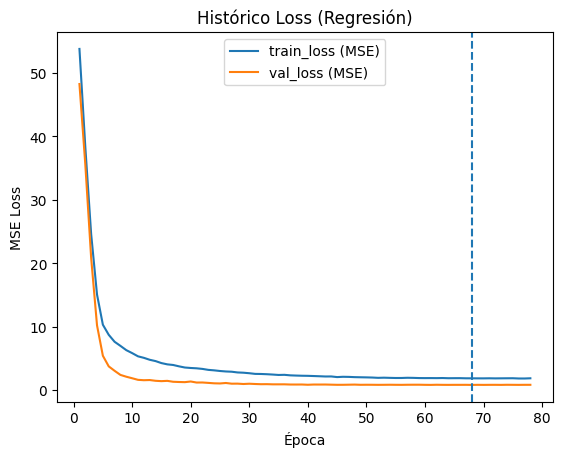


--- Evaluación Final en Conjunto de Test ---

--- Evaluando modelo de regresión como clasificación (Umbral=1400 shares) ---

Accuracy (Regresión como Clasificación): 64.06%

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.62      0.58      0.60      3697
         1.0       0.65      0.69      0.67      4232

    accuracy                           0.64      7929
   macro avg       0.64      0.64      0.64      7929
weighted avg       0.64      0.64      0.64      7929


Matriz de Confusión:
[[2155 1542]
 [1308 2924]]


{'acc': 0.6405599697313659,
 'cm': array([[2155, 1542],
        [1308, 2924]]),
 'report_dict': {'0.0': {'precision': 0.6222928097025701,
   'recall': 0.5829050581552611,
   'f1-score': 0.6019553072625698,
   'support': 3697.0},
  '1.0': {'precision': 0.6547245857590686,
   'recall': 0.6909262759924386,
   'f1-score': 0.6723384686134743,
   'support': 4232.0},
  'accuracy': 0.6405599697313659,
  'macro avg': {'precision': 0.6385086977308193,
   'recall': 0.6369156670738498,
   'f1-score': 0.6371468879380221,
   'support': 7929.0},
  'weighted avg': {'precision': 0.6396028458068835,
   'recall': 0.6405599697313659,
   'f1-score': 0.6395213986785148,
   'support': 7929.0}}}

In [16]:
# --- Bloque 4: Ejecutar el Experimento de Regresión ---

print("\n--- Iniciando Entrenamiento (Regresión + SiLU) ---")
set_seed(42)

# Usamos la mejor configuración encontrada en tu Grid Search (similar al Modelo 12)
# La clase FFNN ya está definida en tu Celda 4
model_reg = FFNN(
    d0, 
    d_hidden=(128, 64, 32), # Tu arquitectura de 3 capas
    dropout=0.5,
    use_bn=True,
    init_method='he',
    act_fn=nn.SiLU # Tu mejor función de activación
)

# Entrenar el modelo de REGRESIÓN (usando fit_regression)
model_reg, history_reg, best_epoch_reg = fit_regression(
    model_reg, 
    ds_train_reg, # <-- Dataset de Regresión
    val_ds=ds_val_reg, # <-- Dataset de Regresión
    epochs=100, 
    lr=1e-3,
    batch_size=256, 
    patience=10, 
    weight_decay=1e-3, # Tu mejor L2
    optimizer_name='AdamW',
    compile_model=False,
    ckpt_path="checkpoints/best_regression_model.pth"
)

print(f"\nMejor época (val_loss MSE): {best_epoch_reg}")

# Graficar historial de regresión (Loss vs Val_Loss)
plt.figure()
plt.plot(history_reg['epoch'], history_reg['loss'], label='train_loss (MSE)')
plt.plot(history_reg['epoch'], history_reg['val_loss'], label='val_loss (MSE)')
if best_epoch_reg:
    plt.axvline(best_epoch_reg, linestyle='--')
plt.xlabel('Época'); plt.ylabel('MSE Loss'); plt.title('Histórico Loss (Regresión)'); plt.legend();
plt.show()


# --- EVALUAR COMO CLASIFICACIÓN ---
# Ahora usamos la nueva función de evaluación
print("\n--- Evaluación Final en Conjunto de Test ---")
evaluate_regression_as_classification(
    model_reg, 
    ds_test_reg, # <-- Dataset de Regresión
    threshold=UMBRAL_POPULARIDAD
)

In [19]:
# --- Bloque de Experimento: Gradient Boosting (LightGBM) [CORREGIDO] ---
print("--- Iniciando Experimento con LightGBM ---")

try:
    # 1. Importar las librerías necesarias (CON LA CORRECCIÓN)
    from lightgbm import LGBMClassifier, early_stopping # <--- CORRECCIÓN AQUÍ
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    
    # 2. Asegurarse de que los datos originales (sin escalar) existan
    if 'X_data' not in locals() or 'y_data' not in locals():
        print("Error: 'X_data' o 'y_data' no encontrados.")
        print("Por favor, asegúrate de haber ejecutado la Celda 7 (Carga de datos) primero.")
    else:
        print(f"Datos originales cargados: {X_data.shape[0]} muestras, {X_data.shape[1]} features.")
        
        # 3. Dividir los datos (SIN ESCALAR)
        X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
            X_data,       # <-- X sin escalar
            y_data,       # <-- y binarizado
            test_size=0.2, 
            stratify=y_data, 
            random_state=42
        )
        
        # 4. Inicializar y Entrenar el modelo
        print("\nEntrenando LGBMClassifier...")
        
        # Primero, creamos un split de validación desde el set de entrenamiento
        X_train_lgbm, X_val_lgbm, y_train_lgbm, y_val_lgbm = train_test_split(
             X_train_orig, y_train_orig,
             test_size=0.25, # 0.25 * 0.8 = 0.2 del total
             stratify=y_train_orig,
             random_state=42
        )
        
        model_lgbm = LGBMClassifier(
            n_estimators=2000,
            learning_rate=0.02,
            n_jobs=-1,
            random_state=42
        )
        
        # Entrenar con early stopping
        model_lgbm.fit(
            X_train_lgbm, 
            y_train_lgbm.ravel(),
            eval_set=[(X_val_lgbm, y_val_lgbm.ravel())],
            eval_metric='logloss',
            # --- CORRECCIÓN AQUÍ ---
            # Se llama directamente a la función 'early_stopping'
            callbacks=[early_stopping(100, verbose=True)]
        )
        
        # 5. Evaluar en el conjunto de Test
        print("\n--- Evaluación de LightGBM en el Conjunto de Test ---")
        y_pred_lgbm = model_lgbm.predict(X_test_orig)
        
        acc_lgbm = accuracy_score(y_test_orig, y_pred_lgbm)
        
        print(f"Accuracy de LightGBM: {acc_lgbm*100:.2f}%")
        print("\nReporte de Clasificación:")
        print(classification_report(y_test_orig, y_pred_lgbm))
        print("\nMatriz de Confusión:")
        print(confusion_matrix(y_test_orig, y_pred_lgbm))

except ImportError:
    print("\nError: 'lightgbm' no está instalado.")
    print("Por favor, instálalo ejecutando: !pip install lightgbm")
except NameError as e:
    print(f"\nError de variable: {e}")
    print("Asegúrate de haber ejecutado la Celda 7 (Carga de datos) primero.")

--- Iniciando Experimento con LightGBM ---
Datos originales cargados: 39644 muestras, 58 features.

Entrenando LGBMClassifier...
[LightGBM] [Info] Number of positive: 11737, number of negative: 12049
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8417
[LightGBM] [Info] Number of data points in the train set: 23786, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.493442 -> initscore=-0.026235
[LightGBM] [Info] Start training from score -0.026235
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[443]	valid_0's binary_logloss: 0.606108

--- Evaluación de LightGBM en el Conjunto de Test ---
Accuracy de LightGBM: 66.99%

Reporte de Clasificación:
              precision    recall  f1-score   support

         

/home/vicente/Desktop/Repostitories/DeepLearning/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
